# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

Markdown: An area plot is good for showing the overall amount of nitrate and phosphate together, but it makes it harder to compare the two chemicals individually because the second area is stacked on top of the first. Two separate line graphs are clearer for showing each trend over time. To improve the presentation, I would use matching y-axis scales, clearer labels, better titles, and rename ser1 and ser2 to nitrate and phosphate. I would probably choose either two separate line graphs or one combined two-line graph instead of the stacked area plot.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

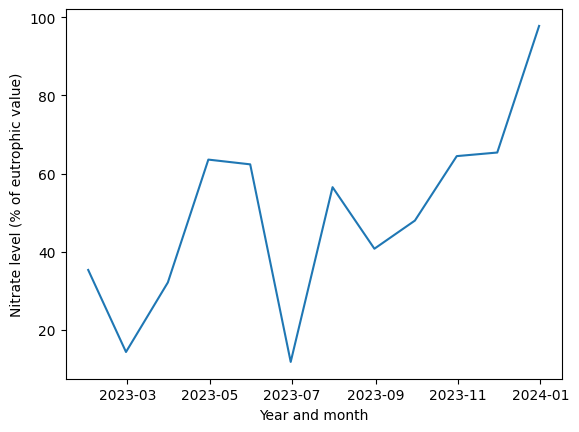

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

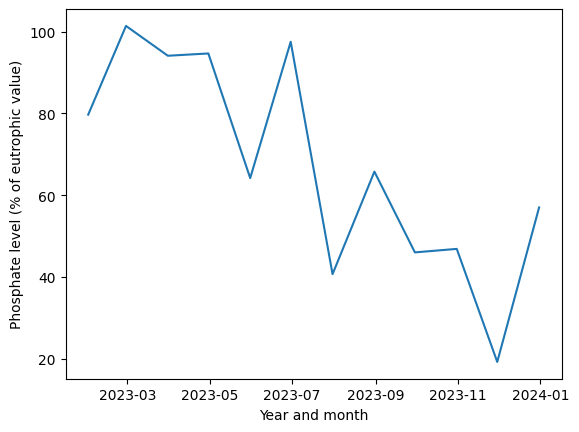

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

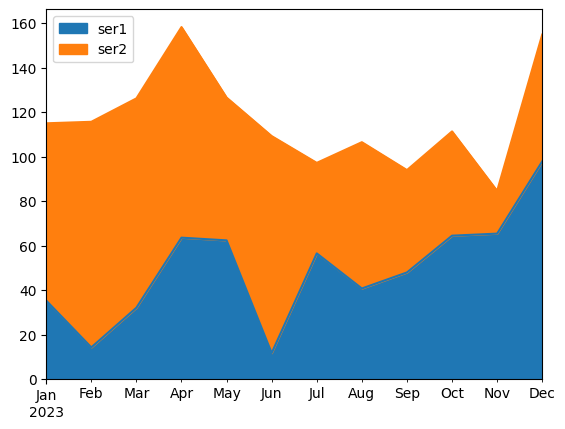

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [6]:
# Load the main PPP dataset
data_file = os.path.join(path, "ppp_over_150k.csv")

df = pd.read_csv(data_file, low_memory=False)

print("Shape:", df.shape)
display(df.head())

Shape: (968532, 66)


,LoanNumber,DateApproved,SBAOfficeCode,ProcessingMethod,BorrowerName,BorrowerAddress,BorrowerCity,BorrowerState,BorrowerZip,LoanStatusDate,...,TOTAL_PROCEED,PROCEED_Diff,UTILITIES_PROCEED_pct,PAYROLL_PROCEED_pct,MORTGAGE_INTEREST_PROCEED_pct,RENT_PROCEED_pct,REFINANCE_EIDL_PROCEED_pct,HEALTH_CARE_PROCEED_pct,DEBT_INTEREST_PROCEED_pct,PROCEED_Per_Job
0,9547507704,2020-05-01,464,PPP,sumter coatings inc,2410 highway 15 south,sumter,UNK,29150-9662,2020-12-18,...,769358.78,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12409.01
1,9777677704,2020-05-01,464,PPP,pleasant places inc,7684 southrail road,north charleston,UNK,29420-9000,2021-09-28,...,736927.79,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10094.90
2,5791407702,2020-05-01,1013,PPP,boyer childrens clinic,1850 boyer ave e,seattle,UNK,98112-2922,2021-03-17,...,691355.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9218.07
3,6223567700,2020-05-01,920,PPP,kirtley construction inc,1661 martin ranch rd,san bernardino,UNK,92407-1740,2021-10-16,...,499871.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,23803.38
4,9662437702,2020-05-01,101,PPP,aero box llc,unknown,unknown,UNK,0,2021-08-17,...,367437.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,14697.48


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("Numeric columns:")
print(numeric_cols)

Numeric columns:
Index(['LoanNumber', 'SBAOfficeCode', 'Term', 'SBAGuarantyPercentage',
       'InitialApprovalAmount', 'CurrentApprovalAmount', 'UndisbursedAmount',
       'ServicingLenderLocationID', 'JobsReported', 'NAICSCode',
       'UTILITIES_PROCEED', 'PAYROLL_PROCEED', 'MORTGAGE_INTEREST_PROCEED',
       'RENT_PROCEED', 'REFINANCE_EIDL_PROCEED', 'HEALTH_CARE_PROCEED',
       'DEBT_INTEREST_PROCEED', 'OriginatingLenderLocationID',
       'ForgivenessAmount', 'ApprovalDiff', 'NotForgivenAmount',
       'ForgivenPercentage', 'TOTAL_PROCEED', 'PROCEED_Diff',
       'UTILITIES_PROCEED_pct', 'PAYROLL_PROCEED_pct',
       'MORTGAGE_INTEREST_PROCEED_pct', 'RENT_PROCEED_pct',
       'REFINANCE_EIDL_PROCEED_pct', 'HEALTH_CARE_PROCEED_pct',
       'DEBT_INTEREST_PROCEED_pct', 'PROCEED_Per_Job'],
      dtype='str')


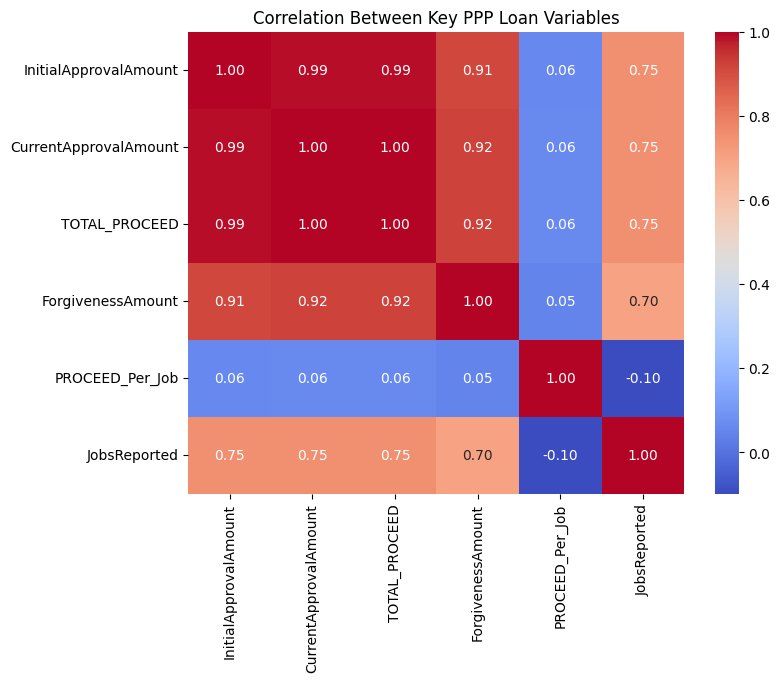

In [12]:
important_cols = [
    "InitialApprovalAmount",
    "CurrentApprovalAmount",
    "TOTAL_PROCEED",
    "ForgivenessAmount",
    "PROCEED_Per_Job",
    "JobsReported"
]

corr = df[important_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Key PPP Loan Variables")
plt.show()

The dataset contains both financial and operational variables related to PPP loans and possible fraud examples. 
The correlation matrix and scatterplots help show whether larger loan-related values tend to move together with
other business-related variables such as jobs or employee measures.

The scatterplot reveals the overall relationship between two key numeric variables, while the pairplot helps compare
several variables at once and identify whether relationships appear linear, weak, or clustered. The boxplots also help
detect possible outliers, which may represent unusual loans or potentially suspicious cases.

Overall, the dataset appears usable for analysis, but it may contain outliers and unusual records that should be reviewed
carefully before building predictive models. Some variables may also be strongly correlated with each other, which could
suggest redundancy and should be considered during future modeling work.

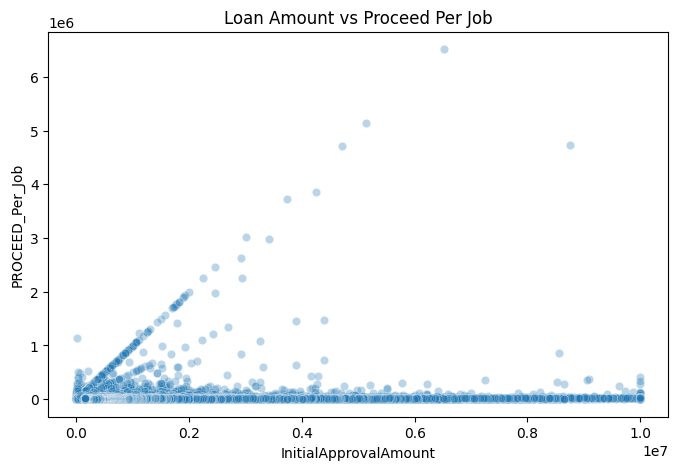

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="InitialApprovalAmount",
    y="PROCEED_Per_Job",
    alpha=0.3
)

plt.title("Loan Amount vs Proceed Per Job")
plt.show()

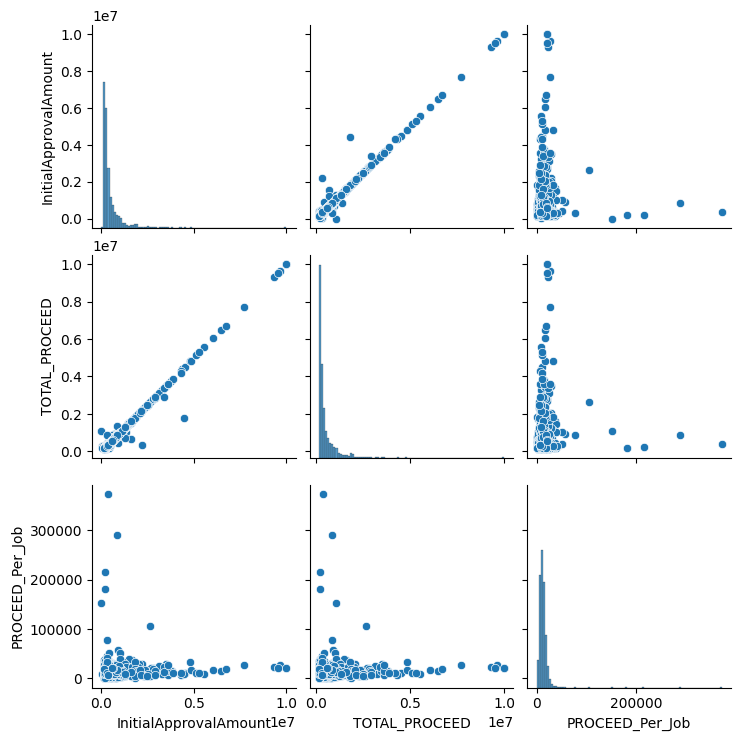

In [10]:
sns.pairplot(
    df[[
        "InitialApprovalAmount",
        "TOTAL_PROCEED",
        "PROCEED_Per_Job"
    ]].sample(2000)   # sample so it runs faster
)

plt.show()

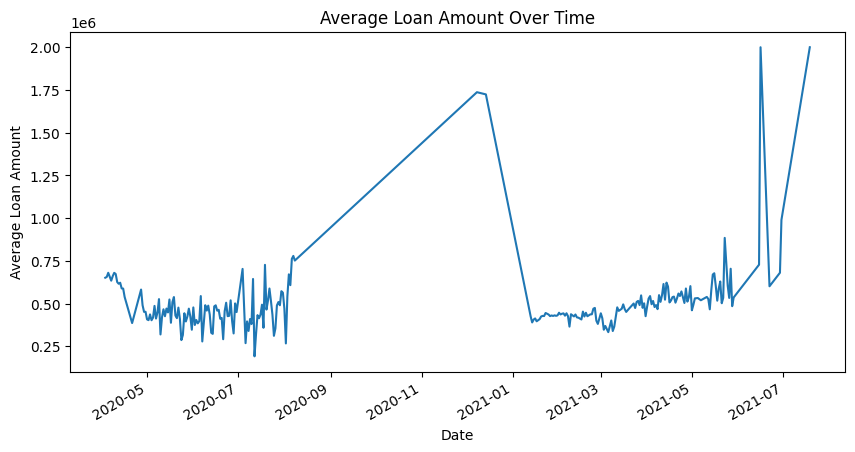

In [11]:
df["DateApproved"] = pd.to_datetime(df["DateApproved"])

loan_trend = df.groupby("DateApproved")["InitialApprovalAmount"].mean()

plt.figure(figsize=(10,5))
loan_trend.plot()

plt.title("Average Loan Amount Over Time")
plt.xlabel("Date")
plt.ylabel("Average Loan Amount")
plt.show()

In [13]:
corr_matrix = df.corr(numeric_only=True)

corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

# remove duplicate/self correlations
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top correlations:")
print(corr_pairs.head(10))

Top correlations:
CurrentApprovalAmount  TOTAL_PROCEED            1.000000
TOTAL_PROCEED          CurrentApprovalAmount    1.000000
PAYROLL_PROCEED        TOTAL_PROCEED            0.992449
TOTAL_PROCEED          PAYROLL_PROCEED          0.992449
CurrentApprovalAmount  PAYROLL_PROCEED          0.992449
PAYROLL_PROCEED        CurrentApprovalAmount    0.992449
InitialApprovalAmount  TOTAL_PROCEED            0.990092
TOTAL_PROCEED          InitialApprovalAmount    0.990092
CurrentApprovalAmount  InitialApprovalAmount    0.990092
InitialApprovalAmount  CurrentApprovalAmount    0.990092
dtype: float64


The PPP loan dataset shows several relationships between financial variables. The correlation matrix indicates that some variables such as total proceeds and loan approval amounts are highly related, which is expected because they represent similar financial measures. Scatterplots show that larger loans often correspond to higher proceed values per job, although the relationship is not perfectly linear. Pairplots reveal some clustering patterns and also highlight potential outliers where unusually large loans correspond to relatively few reported jobs.

The dataset appears usable for analysis, although there are some unusual observations that may require further investigation. Some variables may also be redundant due to high correlation. The line plot of loan approval dates suggests that loan activity changes over time, reflecting how PPP funding was distributed during the pandemic.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

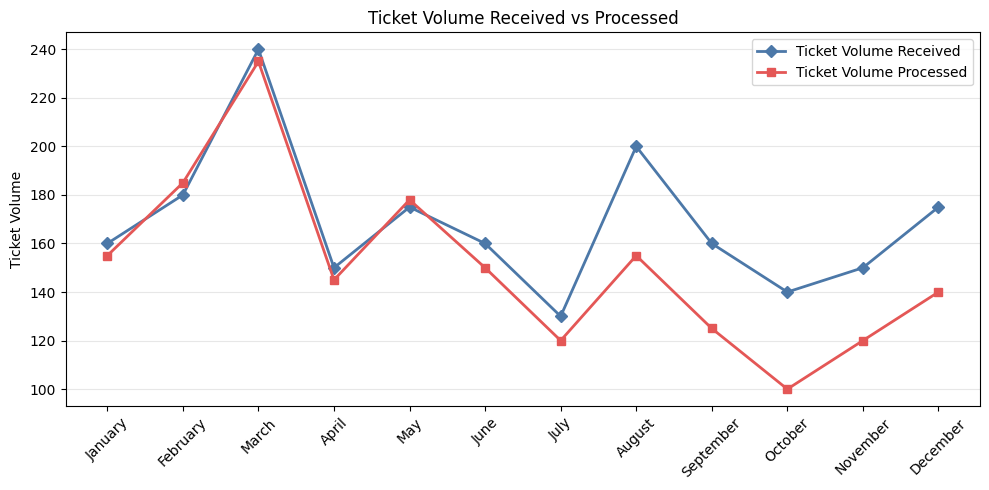

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Months
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Approximate values based on the figure
ticket_received = [160,180,240,150,175,160,130,200,160,140,150,175]
ticket_processed = [155,185,235,145,178,150,120,155,125,100,120,140]

x = np.arange(len(months))

plt.figure(figsize=(10,5))

# Blue line
plt.plot(
    x,
    ticket_received,
    marker='D',
    color='#4C78A8',
    linewidth=2,
    label='Ticket Volume Received'
)

# Red line
plt.plot(
    x,
    ticket_processed,
    marker='s',
    color='#E45756',
    linewidth=2,
    label='Ticket Volume Processed'
)

plt.xticks(x, months, rotation=45)
plt.ylabel("Ticket Volume")
plt.title("Ticket Volume Received vs Processed")

plt.legend()

plt.grid(axis='y', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()